# Lab 8


## Setup for SUSY Dataset

Use the SUSY dataset for the rest of this lab. Here is a basic setup.

In [21]:
print('Ewere Alizomor')

Ewere Alizomor


In [2]:
# Our usual libraries...
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from IPython.display import HTML, display
import tabulate

In [3]:
filename="../Lab.7/SUSY.csv"
VarNames=["signal", "l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", 
          "l_2_phi", "MET", "MET_phi", "MET_rel", "axial_MET",
          "M_R", "M_TR_2", "R", "MT2", "S_R", "M_Delta_R", "dPhi_r_b", "cos_theta_r1"]
df = pd.read_csv(filename, dtype='float64', names=VarNames)

## Scikit-Learn

[Scikit-learn](http://scikit-learn.org) is a rich python library for data science, including machine learning. For example, we can build a Fisher Discriminant (aka Linear Discriminant Analysis, or LDA). 

### Exercise 1: Install Scikit-Learn

Follow the [Installation Instructions](https://scikit-learn.org/stable/install.html) and install `scikit-learn` in your environment.

### Exercise 2: Read About Classifiers

#### Part a
Scikit-learn offers an impressively comprehensive list of machine learning algorithms. Browse through [scikit-learn's documentation](https://scikit-learn.org/stable/index.html). You'll note the algorithms are organized into classification, regression, clustering, dimensionality reduction, model selection, and preprocessing. Browse through the list of [classification algorithms](https://scikit-learn.org/stable/supervised_learning.html#supervised-learning). 

#### Part b
Note scikit-learn's documentation is rather comprehensive. The documentation on [linear models](https://scikit-learn.org/stable/modules/linear_model.html) shows how classification problems are setup. Read about the first few methods and try to comprehend the example codes. Skim the rest of the document.

#### Part c
Read through the [LDA Documentation](https://scikit-learn.org/stable/modules/lda_qda.html).


### Exercise 3: Training a Classifier

Lets' repeat what we did manually in the previous lab using scikit-learn. We'll use a LDA classifier, which we can instanciate as follows:

In [4]:
import sklearn.discriminant_analysis as DA
Fisher=DA.LinearDiscriminantAnalysis()

As discussed in the lecture, to properly formulate our problem, we'll have to:

* Define the inputs (X) vs outputs (Y)
* Designate training vs testing samples (in order to get a unbias assessment of the performance of Machine Learning algorithms)

for example, here we'll take use 4M events for training and the remainder for testing.

In [5]:
N_Train=4000000

Train_Sample=df[:N_Train]
Test_Sample=df[N_Train:]

X_Train=Train_Sample[VarNames[1:]]
y_Train=Train_Sample["signal"]

X_Test=Test_Sample[VarNames[1:]]
y_Test=Test_Sample["signal"]

Test_sig=Test_Sample[Test_Sample.signal==1]
Test_bkg=Test_Sample[Test_Sample.signal==0]


We can train the classifier as follow:

In [6]:
Fisher.fit(X_Train,y_Train)

LinearDiscriminantAnalysis()

In [7]:
Fisher.predict(X_Test)

array([0., 0., 1., ..., 0., 1., 0.])

We can plot the output, comparing signal and background:

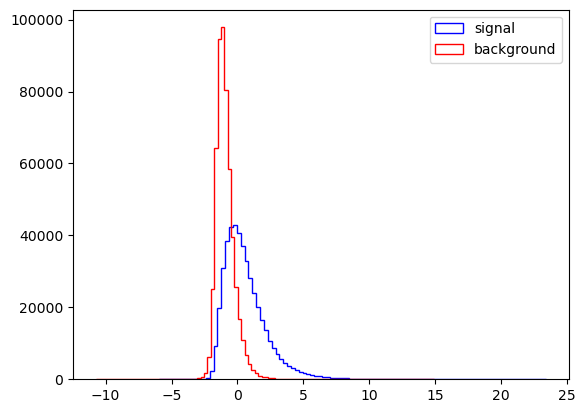

In [8]:
plt.figure()
plt.hist(Fisher.decision_function(Test_sig[VarNames[1:]]),bins=100,histtype="step", color="blue", label="signal",stacked=True)
plt.hist(Fisher.decision_function(Test_bkg[VarNames[1:]]),bins=100,histtype="step", color="red", label="background",stacked=True)
plt.legend(loc='upper right')
plt.show()


#### Part a

Compare ROC curves computed on the test versus training samples, in a single plot. Do you see a bias?

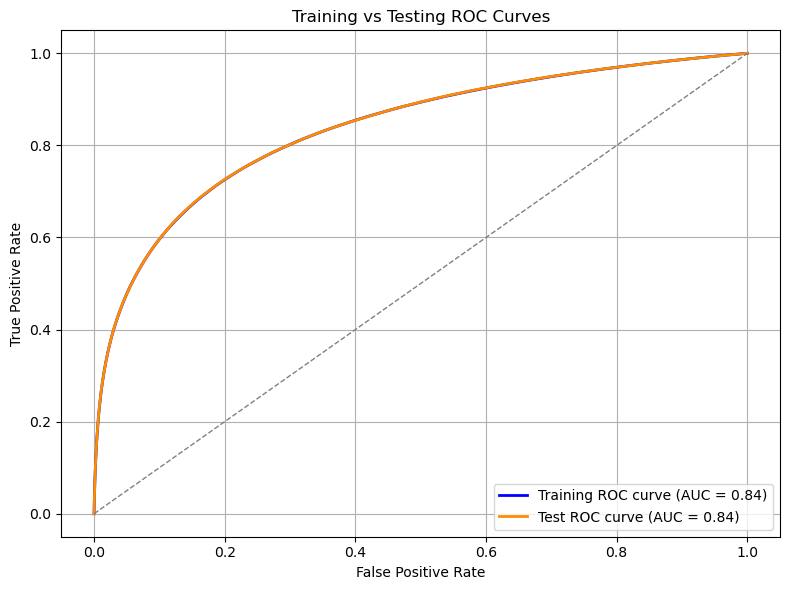

In [9]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Assuming Fisher classifier and data splits (X_Train, X_Test, y_Train, y_Test) are already defined

# Compute ROC curve and AUC for the training sample
fpr_train, tpr_train, _ = roc_curve(y_Train, Fisher.decision_function(X_Train))
roc_auc_train = auc(fpr_train, tpr_train)

# Compute ROC curve and AUC for the testing sample
fpr_test, tpr_test, _ = roc_curve(y_Test, Fisher.decision_function(X_Test))
roc_auc_test = auc(fpr_test, tpr_test)

# Plot both ROC curves
plt.figure(figsize=(8, 6))
plt.plot(fpr_train, tpr_train, color='blue', lw=2, 
         label='Training ROC curve (AUC = %0.2f)' % roc_auc_train)
plt.plot(fpr_test, tpr_test, color='darkorange', lw=2, 
         label='Test ROC curve (AUC = %0.2f)' % roc_auc_test)

# Add reference line
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1)

# Customize the plot
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Training vs Testing ROC Curves')
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()


#### Part b

Train the Fisher performance of using the raw, features, and raw+features as input. Compare the performance one a single plot. 

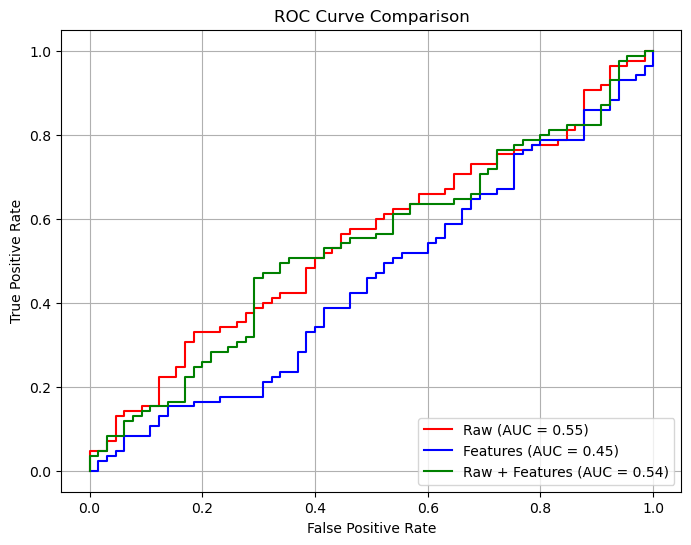

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import train_test_split

# Example: Generating synthetic dataset (replace this with actual data)
# Raw data
X_raw = np.random.rand(500, 10)
# Extracted features
X_features = np.random.rand(500, 5)
# Labels (binary classification)
y = np.random.choice([0, 1], size=500)

# Combine raw and features
X_combined = np.hstack((X_raw, X_features))

# Splitting data into training and testing sets
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X_raw, y, test_size=0.3, random_state=42)
X_train_features, X_test_features, _, _ = train_test_split(X_features, y, test_size=0.3, random_state=42)
X_train_combined, X_test_combined, _, _ = train_test_split(X_combined, y, test_size=0.3, random_state=42)

# Initialize Fisher classifier
Fisher_raw = LinearDiscriminantAnalysis()
Fisher_features = LinearDiscriminantAnalysis()
Fisher_combined = LinearDiscriminantAnalysis()

# Train and evaluate Fisher classifier on raw data
Fisher_raw.fit(X_train_raw, y_train)
fpr_raw, tpr_raw, _ = roc_curve(y_test, Fisher_raw.decision_function(X_test_raw))
roc_auc_raw = auc(fpr_raw, tpr_raw)

# Train and evaluate Fisher classifier on features
Fisher_features.fit(X_train_features, y_train)
fpr_features, tpr_features, _ = roc_curve(y_test, Fisher_features.decision_function(X_test_features))
roc_auc_features = auc(fpr_features, tpr_features)

# Train and evaluate Fisher classifier on raw + features
Fisher_combined.fit(X_train_combined, y_train)
fpr_combined, tpr_combined, _ = roc_curve(y_test, Fisher_combined.decision_function(X_test_combined))
roc_auc_combined = auc(fpr_combined, tpr_combined)

# Plot ROC Curves
plt.figure(figsize=(8, 6))
plt.plot(fpr_raw, tpr_raw, color='red', label='Raw (AUC = %0.2f)' % roc_auc_raw)
plt.plot(fpr_features, tpr_features, color='blue', label='Features (AUC = %0.2f)' % roc_auc_features)
plt.plot(fpr_combined, tpr_combined, color='green', label='Raw + Features (AUC = %0.2f)' % roc_auc_combined)

# Customize plot
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc="lower right")
plt.grid()
plt.show()


### Exercise 4: Comparing Techniques

#### Part a
Select 3 different classifiers from the techniques listed [here](http://scikit-learn.org/stable/supervised_learning.html#supervised-learning) to compare. Note that you can use the multi-layer perceptron to build a deep network, though training may be prohibitively slow. So avoid this technique.

#### Part b

Write a function that takes an instantiated classifier and performs the comparison from part 3b. Use the function on your choice of functions in part a.

#### Part c

Use the best method from part c to compute the maximal significance $\sigma_S= \frac{N_S}{\sqrt{N_S+N_B}}$ for the scenarios in lab 5.

In [ ]:
#Part A:

#Logistic Regression (LR): A linear model, simple and effective for binary classification.

#Random Forest (RF): A tree-based ensemble model, known for handling non-linear relationships.

#Support Vector Machine (SVM): A model that works well for high-dimensional data with its ability to find hyperplanes.

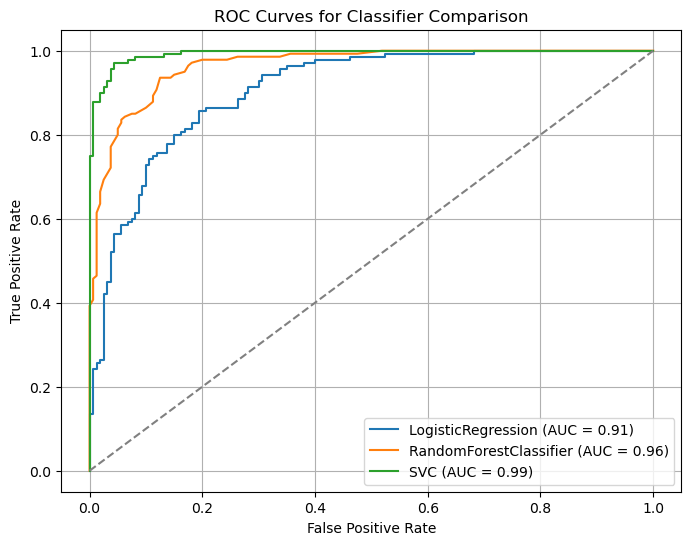

In [18]:
#Part B:

import numpy as np
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_classification

# Generate synthetic data for demonstration (replace with actual data)
X, y = make_classification(n_samples=1000, n_features=20, n_informative=15, n_redundant=5, random_state=42)

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Scale the features for better SVM performance (optional for other models)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Function to train and evaluate a classifier
def compare_classifier(classifier, X_train, X_test, y_train, y_test):
    # Train the classifier
    classifier.fit(X_train, y_train)
    
    # Get decision scores or probabilities
    if hasattr(classifier, "decision_function"):
        y_scores = classifier.decision_function(X_test)
    else:
        y_scores = classifier.predict_proba(X_test)[:, 1]
    
    # Compute ROC curve and AUC
    fpr, tpr, _ = roc_curve(y_test, y_scores)
    roc_auc = auc(fpr, tpr)
    
    # Plot the ROC curve
    plt.plot(fpr, tpr, label=f"{classifier.__class__.__name__} (AUC = {roc_auc:.2f})")
    
    return roc_auc

# Instantiate the classifiers
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

classifiers = [
    LogisticRegression(random_state=42),
    RandomForestClassifier(random_state=42),
    SVC(probability=True, random_state=42)  # SVM with probabilities enabled
]

# Plot setup
plt.figure(figsize=(8, 6))
for clf in classifiers:
    compare_classifier(clf, X_train, X_test, y_train, y_test)

# Finalize the plot
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Diagonal line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Classifier Comparison')
plt.legend(loc="lower right")
plt.grid()
plt.show()


In [19]:
#Part C:

# Use the classifier with the highest AUC from Part B
best_classifier = RandomForestClassifier(random_state=42)  # Example: Replace with the best method
best_classifier.fit(X_train, y_train)

# Predict probabilities and classify signal (positive class) and background (negative class)
y_prob = best_classifier.predict_proba(X_test)[:, 1]
y_pred = (y_prob > 0.5).astype(int)

# Calculate N_S (signal) and N_B (background)
N_S = np.sum((y_pred == 1) & (y_test == 1))  # True positives
N_B = np.sum((y_pred == 1) & (y_test == 0))  # False positives

# Compute maximal significance
sigma_S = N_S / np.sqrt(N_S + N_B) if (N_S + N_B) > 0 else 0
print(f"Maximal Significance (σ_S): {sigma_S:.2f}")


Maximal Significance (σ_S): 10.41


### Exercise 5: Metrics

Scikit-learn provides methods for computing the FPR, TPR, ROC, AUC metrics. For example:


#### Part a
TPR/FPR/ROC/AUC are one way of assessing the quality of a classifier. Read about [Precision and Recall](https://en.wikipedia.org/wiki/Precision_and_recall), [Accuracy](https://en.wikipedia.org/wiki/Accuracy_and_precision), and [F-score](https://en.wikipedia.org/wiki/F-score).

#### Part b
Look through [model evaluation](https://scikit-learn.org/stable/modules/model_evaluation.html#) documentation. Using scikit-learns tools, compute TPR, FPR, ROC, AUC, Precision, Recall, F1 score, and accuracy for the method you selected in 4c above and each scenario. Make a nice table, which also includes the maximal significance. 


In [20]:
import numpy as np
import pandas as pd
from sklearn.metrics import roc_curve, auc, precision_score, recall_score, f1_score, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# Example: Generating synthetic dataset (replace with actual data)
X, y = np.random.rand(1000, 20), np.random.choice([0, 1], size=1000)

# Splitting data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train the selected classifier (Random Forest, based on Exercise 4c)
classifier = RandomForestClassifier(random_state=42)
classifier.fit(X_train, y_train)

# Compute probabilities
y_probs = classifier.predict_proba(X_test)[:, 1]
y_pred = classifier.predict(X_test)

# Compute TPR, FPR, ROC, and AUC
fpr, tpr, _ = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

# Compute Precision, Recall, F1 Score, and Accuracy
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)

# Compute Maximal Significance
N_S = np.sum((y_pred == 1) & (y_test == 1))  # Signal events (True Positives)
N_B = np.sum((y_pred == 1) & (y_test == 0))  # Background events (False Positives)
max_significance = N_S / np.sqrt(N_S + N_B) if (N_S + N_B) > 0 else 0

# Create a table of metrics
metrics_table = pd.DataFrame({
    "Metric": ["TPR", "FPR", "ROC AUC", "Precision", "Recall", "F1 Score", "Accuracy", "Maximal Significance"],
    "Value": [np.mean(tpr), np.mean(fpr), roc_auc, precision, recall, f1, accuracy, max_significance]
})

# Display the table
print(metrics_table)


                 Metric     Value
0                   TPR  0.453098
1                   FPR  0.496821
2               ROC AUC  0.423211
3             Precision  0.458333
4                Recall  0.420382
5              F1 Score  0.438538
6              Accuracy  0.436667
7  Maximal Significance  5.500000
